**This script performs a complete pipeline for preparing and tokenizing a single-cell transcriptomic dataset (pancreas) for use with Geneformer, followed by training/testing setup and model evaluation.**

Here's a structured summary:

**🔧 1. Environment Setup and Package Installation**

Installs Python packages: scanpy, loompy, datasets.

Clones the Geneformer repository.

Installs Geneformer in editable mode.

Mounts Google Drive for data access/storage.

**📥 2. Data Acquisition and Preprocessing**

Downloads pancreas dataset (.h5ad) and GENCODE gene annotation (.gtf).

Loads the AnnData object (pancreas_scib.h5ad) using scanpy.

Inspects and prints metadata: observations (obs, i.e. cells) and variables (var, i.e. genes).

Converts gene names to Ensembl IDs using the .gtf annotation.

Updates .obs with n_counts and computes number of expressed genes per cell.

**💾 3. Save Data**

Saves the annotated dataset as .h5ad and .loom (Geneformer-compatible format) both locally and to Google Drive.

**🧪 4. Verify .loom Content**

Uses loompy to open the .loom file.

Verifies presence of required metadata:

Ensembl IDs in gene metadata (.ra)

n_counts in cell metadata (.ca)

Prints metadata heads for manual inspection.

**🧬 5. Tokenization (Geneformer Input Conversion)**

Initializes a TranscriptomeTokenizer from Geneformer with V1 settings.

Tokenizes the .loom dataset to .dataset format (Hugging Face datasets).

The code was adapted from : https://github.com/Antwerp2004/Geneformer/blob/main/download_and_prepare_datasets.ipynb

In [1]:
!pip install scanpy
!pip install loompy
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.6/168.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.4 MB/s eta 0:00:00
  Created wheel for loompy: filename=loompy-3.0.8-py3-none-any.whl size=54012 sha256=ebae6826bdea108132096409757014fd349f9dc924cba0dd8a73b16d7eba43d5
  Stored in directory: /root/.cache/pip/wheels/0a/65/00/30ea772562c1e326e9a076e6a526216abc6c5456852cc2e0e4
Successfully built loompy


In [2]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!ls -1

Git LFS initialized.
Cloning into 'Geneformer'...
remote: Enumerating objects: 1193, done.
remote: Counting objects: 100% (493/493), done.
remote: Compressing objects: 100% (492/492), done.
remote: Total 1193 (delta 308), reused 0 (delta 0), pack-reused 700 (from 1)
Receiving objects: 100% (1193/1193), 5.75 MiB | 16.50 MiB/s, done.
Resolving deltas: 100% (735/735), done.
Filtering content: 100% (24/24), 3.32 GiB | 151.43 MiB/s, done.
Geneformer
sample_data


In [3]:
%cd Geneformer
!pip install -e .

/content/Geneformer
Obtaining file:///content/Geneformer
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.2 MB/s eta 0:00:00
   ━━━━

https://github.com/Antwerp2004/Geneformer/blob/main/download_and_prepare_datasets.ipynb

In [4]:
import os
import scanpy as sc
import numpy as np
import loompy
from geneformer import TranscriptomeTokenizer
from datasets import load_from_disk

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
!pwd

/content/Geneformer


In [6]:
# Download dataset
!wget --timeout=0 --no-check-certificate 'https://s3.us-west-2.amazonaws.com/cdn.bioturing.com/colab/data/geneformer_data.zip'
!unzip -o geneformer_data.zip

--2025-07-17 19:48:47--  https://s3.us-west-2.amazonaws.com/cdn.bioturing.com/colab/data/geneformer_data.zip
Resolving s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)... 52.92.187.24, 52.92.213.48, 52.92.146.72, ...
Connecting to s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)|52.92.187.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1702638061 (1.6G) [application/zip]
Saving to: ‘geneformer_data.zip’

geneformer_data.zip 100%[===================>]   1.58G  37.7MB/s    in 50s     

2025-07-17 19:49:37 (32.6 MB/s) - ‘geneformer_data.zip’ saved [1702638061/1702638061]

Archive:  geneformer_data.zip
   creating: data/
  inflating: data/token_dictionary_gc30M.pkl  
   creating: data/gene_30m_100k.dataset/
  inflating: data/gene_30m_100k.dataset/cache-c8215c4830d54d54.arrow  
  inflating: data/gene_30m_100k.dataset/cache-d514b929742d82e3.arrow  
  inflating: data/gene_30m_100k.dataset/cache-36825fa645e327c9.arrow  
  inflating: data/gene_30m_100k

In [7]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# Copy to Google Drive
# !cp geneformer_data.zip '/content/drive/My Drive/geneformer_test2'

In [8]:
# # Download gene annotation information from ebi
!wget  --timeout=0 --no-check-certificate https://s3.us-west-2.amazonaws.com/cdn.bioturing.com/colab/data/gencode.v44.annotation.gtf.gz
import os
os.system(f"/usr/bin/yes y | gunzip gencode.v44.annotation.gtf.gz")

# Copy to Google Drive
# !cp gencode.v44.annotation.gtf '/content/drive/My Drive/geneformer_test2'

--2025-07-17 19:50:33--  https://s3.us-west-2.amazonaws.com/cdn.bioturing.com/colab/data/gencode.v44.annotation.gtf.gz
Resolving s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)... 52.218.218.144, 52.92.136.8, 52.92.148.112, ...
Connecting to s3.us-west-2.amazonaws.com (s3.us-west-2.amazonaws.com)|52.218.218.144|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49721965 (47M) [binary/octet-stream]
Saving to: ‘gencode.v44.annotation.gtf.gz’

gencode.v44.annotat 100%[===================>]  47.42M  43.2MB/s    in 1.1s    

2025-07-17 19:50:35 (43.2 MB/s) - ‘gencode.v44.annotation.gtf.gz’ saved [49721965/49721965]



0

In [9]:
!pwd
!echo -e "\nContent of Geneformer folder\n"
%cd /content/Geneformer/
!ls -1
!echo -e "\nContent of Geneformer data\n"
!ls -1 ./geneformer_data/data/
!echo -e "\nContent of Geneformer data : pancreas model\n"
!ls -1 ./geneformer_data/data/pancreas_model/

/content/Geneformer

Content of Geneformer folder

/content/Geneformer
config.json
data
docs
examples
fine_tuned_models
gencode.v44.annotation.gtf
geneformer
geneformer_data.zip
geneformer.egg-info
Geneformer-V1-10M
Geneformer-V2-104M
Geneformer-V2-104M_CLcancer
Geneformer-V2-316M
generation_config.json
MANIFEST.in
model.safetensors
README.md
requirements.txt
setup.py
training_args.bin

Content of Geneformer data

ls: cannot access './geneformer_data/data/': No such file or directory

Content of Geneformer data : pancreas model

ls: cannot access './geneformer_data/data/pancreas_model/': No such file or directory


In [10]:
import scanpy as sc

data_h5ad = sc.read_h5ad('data/pancreas_scib.h5ad')
data_h5ad

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors', 'batch'
    layers: 'counts'

In [11]:
# Display basic info about the AnnData object
print(data_h5ad)

# Get dimensions
print(f"Shape: {data_h5ad.shape}")
print(f"Number of cells: {data_h5ad.n_obs}")
print(f"Number of genes: {data_h5ad.n_vars}")

# View Observations (Cells)
# View observation metadata (cell information)

print("\nObservation columns:\n")
print(data_h5ad.obs.columns.tolist())

# View first few rows of obs
print("\nFirst 5 observations:\n")
print(data_h5ad.obs.head())

# Get specific observation info
print(data_h5ad.obs.info())

# View Variables (Genes)

# View variable metadata (gene information)
print("\nVariable columns (GENES):\n")
print(data_h5ad.var.columns.tolist())

# View first few rows of var
print("\nFirst 5 variables:\n")
print(data_h5ad.var.head())

# Get specific variable info : View Gene Names
print(data_h5ad.var.info())

# View gene names (index of var)
print("\nFirst 10 gene names:\n")
print(data_h5ad.var_names[:10].tolist())

# Search for specific genes

gene_of_interest = "INS"  # example
matching_genes = data_h5ad.var_names[data_h5ad.var_names.str.contains(gene_of_interest, case=False)]
print(f"Genes containing '{gene_of_interest}':")
print(matching_genes.tolist())

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors', 'batch'
    layers: 'counts'
Shape: (16382, 19093)
Number of cells: 16382
Number of genes: 19093

Observation columns:

['tech', 'celltype', 'size_factors', 'batch']

First 5 observations:

              tech celltype  size_factors   batch
D101_5      celseq    gamma      0.028492  celseq
D101_43     celseq    gamma      0.079348  celseq
D101_93     celseq    gamma      0.037932  celseq
D102_4      celseq    gamma      0.047685  celseq
D172444_23  celseq    gamma      0.038683  celseq
<class 'pandas.core.frame.DataFrame'>
Index: 16382 entries, D101_5 to Sample_1600
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   tech          16382 non-null  category
 1   celltype      16382 non-null  category
 2   size_factors  16382 non-null  float64 
 3   batch         16382 non-null  category
dtypes: category(3), float64(1)
memo

Cell type counts:
celltype
alpha                 5493
beta                  4169
ductal                2142
acinar                1669
delta                 1055
gamma                  699
activated_stellate     464
endothelial            313
quiescent_stellate     193
macrophage              79
mast                    42
epsilon                 32
schwann                 25
t_cell                   7
Name: count, dtype: int64

Unique cell types (14):
['gamma', 'acinar', 'alpha', 'delta', 'beta', ..., 'mast', 'macrophage', 'epsilon', 'quiescent_stellate', 't_cell']
Length: 14
Categories (14, object): ['acinar', 'activated_stellate', 'alpha', 'beta', ..., 'mast',
                          'quiescent_stellate', 'schwann', 't_cell']

Total number of cell types: 14


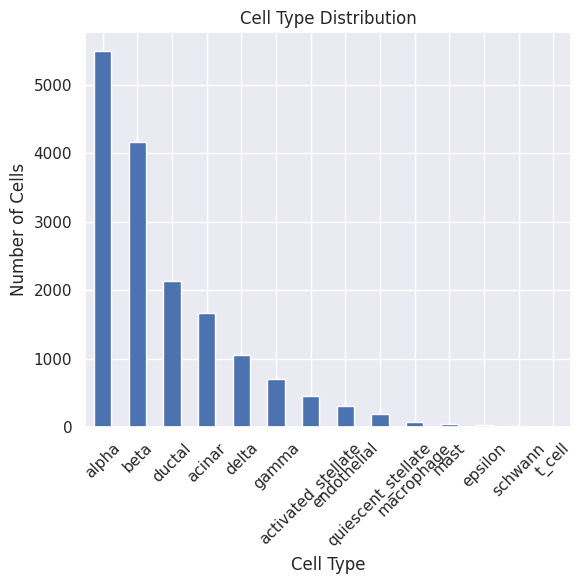

In [12]:
# Count unique cell types
# Get unique cell types and their counts

celltype_counts = data_h5ad.obs['celltype'].value_counts()
print("Cell type counts:")
print(celltype_counts)

# Get just the unique cell types
unique_celltypes = data_h5ad.obs['celltype'].unique()
print(f"\nUnique cell types ({len(unique_celltypes)}):")
print(unique_celltypes)

# Get number of unique cell types
n_celltypes = data_h5ad.obs['celltype'].nunique()
print(f"\nTotal number of cell types: {n_celltypes}")

import matplotlib.pyplot as plt

# Create a bar plot of cell type counts
plt.figure(figsize=(6, 6))
celltype_counts.plot(kind='bar')
plt.title('Cell Type Distribution')
plt.xlabel('Cell Type')
plt.ylabel('Number of Cells')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Create a dictionary to map gene names to Ensembl IDs
ensembl_mapping = {}
with open('gencode.v44.annotation.gtf', 'r') as gtf_file:
    for line in gtf_file:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if parts[2] == 'gene':
            attributes = parts[-1].split('; ')
            gene_name = None
            gene_id = None
            for attr in attributes:
                if attr.startswith('gene_name'):
                    gene_name = attr.split('"')[1]
                elif attr.startswith('gene_id'):
                    gene_id = attr.split('"')[1]
            if gene_name and gene_id:
                ensembl_mapping[gene_name] = gene_id

In [14]:
# Function to convert gene names to Ensembl IDs
def convert_gene_name_to_ensembl(gene_name):
    return ensembl_mapping.get(gene_name, gene_name)  # Return the Ensembl ID if found, or the original gene name if not

In [15]:
# Apply the conversion function to the gene names in your AnnData object
data_h5ad.var['ensembl_id'] = data_h5ad.var_names.map(convert_gene_name_to_ensembl)

In [16]:
for i in range(len(data_h5ad.var['ensembl_id'])):
    data_h5ad.var['ensembl_id'][i] = data_h5ad.var['ensembl_id'][i].split(".")[0]

In [17]:
data_h5ad.var['ensembl_id']

,ensembl_id
A1BG,ENSG00000121410
A1CF,ENSG00000148584
A2M,ENSG00000175899
A2ML1,ENSG00000166535
A4GALT,ENSG00000128274
...,...
ZXDC,ENSG00000070476
ZYG11B,ENSG00000162378
ZYX,ENSG00000159840
ZZEF1,ENSG00000074755


In [18]:
ensembl_ids = data_h5ad.var['ensembl_id']

In [19]:
for i in range(len(data_h5ad.var.index)):
    data_h5ad.var.index.values[i] = ensembl_ids[i]

In [20]:
data_h5ad.obs["n_counts"] = data_h5ad.obs.iloc[:,1]
data_h5ad.obs.iloc[:,1]

print(data_h5ad.obs.columns)
data_h5ad.obs.head()

Index(['tech', 'celltype', 'size_factors', 'batch', 'n_counts'], dtype='object')


,tech,celltype,size_factors,batch,n_counts
D101_5,celseq,gamma,0.028492,celseq,gamma
D101_43,celseq,gamma,0.079348,celseq,gamma
D101_93,celseq,gamma,0.037932,celseq,gamma
D102_4,celseq,gamma,0.047685,celseq,gamma
D172444_23,celseq,gamma,0.038683,celseq,gamma


In [21]:
unique_techs = data_h5ad.obs["tech"].unique()
print("Unique technologies:", unique_techs)
print("Number of unique technologies:", len(unique_techs))
print(data_h5ad.obs["tech"].unique())

Unique technologies: ['celseq', 'celseq2', 'fluidigmc1', 'smartseq2', 'inDrop1', 'inDrop2', 'inDrop3', 'inDrop4', 'smarter']
Categories (9, object): ['celseq', 'celseq2', 'fluidigmc1', 'inDrop1', ..., 'inDrop3', 'inDrop4',
                         'smarter', 'smartseq2']
Number of unique technologies: 9
['celseq', 'celseq2', 'fluidigmc1', 'smartseq2', 'inDrop1', 'inDrop2', 'inDrop3', 'inDrop4', 'smarter']
Categories (9, object): ['celseq', 'celseq2', 'fluidigmc1', 'inDrop1', ..., 'inDrop3', 'inDrop4',
                         'smarter', 'smartseq2']


In [22]:
num_features_per_cell = np.sum(data_h5ad.X > 0, axis=1)

# Create a new column in adata.obs to store the number of features per cell
data_h5ad.obs['n_counts'] = num_features_per_cell

In [23]:
data_h5ad

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors', 'batch', 'n_counts'
    var: 'ensembl_id'
    layers: 'counts'

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
print("Directory exists:", os.path.exists("/content/drive/My Drive/geneformer_test2/"))
print("Contents:", os.listdir("/content/drive/My Drive/geneformer_test2/"))

Directory exists: True
Contents: ['geneformer_data.zip', 'gencode.v44.annotation.gtf', 'pancreas_h5ad.h5ad', 'pancreas_scib.h5ad', 'pancreas_scib.loom', 'pancreas_scib.dataset', 'pancreas_ensembl_scib.h5ad', 'pancreas_ensembl_scib.loom', 'pancreas_scib_V1model.dataset', 'pancreas_scib_V2model.dataset']


In [26]:
data_h5ad.write("/content/drive/My Drive/geneformer_test2/pancreas_ensembl_scib.h5ad")
# data_h5ad.write_loom("/content/drive/My Drive/geneformer_test2/pancreas_scib.loom")

In [27]:
data_h5ad.write("/content/Geneformer/pancreas_ensembl_scib.h5ad")

In [28]:
data_h5ad

AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors', 'batch', 'n_counts'
    var: 'ensembl_id'
    layers: 'counts'

In [29]:
!pwd

!echo -e "\nContent of Geneformer folder\n"
!ls -1

!echo -e "\nContent of Geneformer data : data\n"
!ls -1 "./data"

!echo -e "\nContent of Geneformer pancreas model :\n"
!ls -1 "./data/pancreas_model"

/content/Geneformer

Content of Geneformer folder

config.json
data
docs
examples
fine_tuned_models
gencode.v44.annotation.gtf
geneformer
geneformer_data.zip
geneformer.egg-info
Geneformer-V1-10M
Geneformer-V2-104M
Geneformer-V2-104M_CLcancer
Geneformer-V2-316M
generation_config.json
MANIFEST.in
model.safetensors
pancreas_ensembl_scib.h5ad
README.md
requirements.txt
setup.py
training_args.bin

Content of Geneformer data : data

cell_type_train_data.dataset
dosage_sens_tf_labels.csv
gene_30m_100k.dataset
gene_info_table.csv
pancreas_model
pancreas_scib.h5ad
token_dictionary_gc30M.pkl

Content of Geneformer pancreas model :

all_results.json
config.json
eval_results.json
predictions.pickle
pytorch_model.bin
training_args.bin


**Step 2: Convert data from AnnData to Loom**

In [30]:
data_h5ad.write_loom("/content/drive/My Drive/geneformer_test2/pancreas_ensembl_scib.loom")
!mkdir pancreas_ensembl_scib_loom
data_h5ad.write_loom("/content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib.loom")

In [31]:
ls -1 /content/Geneformer/pancreas_ensembl_scib_loom/

pancreas_ensembl_scib.loom


Verifying that pancreas_ensembl_scib.loom contains all required information for running Geneformer — specifically:

**Ensembl gene IDs in the gene metadata**

and

**n_counts in the cell metadata.**

In [32]:
import pandas as pd

with loompy.connect('/content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib.loom') as ds:
    # Basic info
    print("Shape of loom file (genes x cells):", ds.shape)

    # Print all row (gene) metadata keys
    print("\nRow attributes (gene metadata):")
    print(ds.ra.keys())   # e.g., ['Gene', 'EnsemblID']

    # Print all column (cell) metadata keys
    print("\nColumn attributes (cell metadata):")
    print(ds.ca.keys())   # e.g., ['cell_type', 'n_counts']

    # Example: print the second gene expression profile (gene index 2)
    print("\nExpression values for gene at index 2 (across all cells):")

    unique_celltypes = set(ds.ca["celltype"])
    print(f"\nNumber of unique cell types: {len(unique_celltypes)}")
    print("\nUnique cell types:\n")
    print(sorted(unique_celltypes))
    print(ds[2, :])  # Accessing gene 2 across all cells

    print("\nNumber of values in that row (should equal number of cells):", len(ds[2, :]))

    # Convert .ra (var / gene metadata) to DataFrame and show head
    var_df = pd.DataFrame({k: v for k, v in ds.ra.items()})
    print("=== var (gene metadata) ===")
    print(var_df.head())

    # Convert .ca (obs / cell metadata) to DataFrame and show head
    obs_df = pd.DataFrame({k: v for k, v in ds.ca.items()})
    print("\n=== obs (cell metadata) ===")
    print(obs_df.head())

Shape of loom file (genes x cells): (19093, 16382)

Row attributes (gene metadata):
['ensembl_id', 'var_names']

Column attributes (cell metadata):
['batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech']

Expression values for gene at index 2 (across all cells):

Number of unique cell types: 14

Unique cell types:

[np.str_('acinar'), np.str_('activated_stellate'), np.str_('alpha'), np.str_('beta'), np.str_('delta'), np.str_('ductal'), np.str_('endothelial'), np.str_('epsilon'), np.str_('gamma'), np.str_('macrophage'), np.str_('mast'), np.str_('quiescent_stellate'), np.str_('schwann'), np.str_('t_cell')]
[0. 0. 0. ... 0. 0. 0.]

Number of values in that row (should equal number of cells): 16382
=== var (gene metadata) ===
        ensembl_id        var_names
0  ENSG00000121410  ENSG00000121410
1  ENSG00000148584  ENSG00000148584
2  ENSG00000175899  ENSG00000175899
3  ENSG00000166535  ENSG00000166535
4  ENSG00000128274  ENSG00000128274

=== obs (cell metadata) ===
    batc

In [33]:
import scanpy as sc
import pickle

# === 1. Load the .loom dataset ===
#adata = sc.read_loom(loom_file)

# === 2. Load the Ensembl mapping dictionary ===
mapping_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/ensembl_mapping_dict_gc30M.pkl"

with open(mapping_file, "rb") as f:
    ensembl_mapping_dict = pickle.load(f)

# === 3. Extract Ensembl IDs from adata correctly ===
# Check that the column exists
if "ensembl_id" not in data_h5ad.var.columns:
    raise ValueError("❌ 'ensembl_id' column not found in adata.var")

# Get Ensembl IDs from that column
ensembl_ids_from_adata = set(data_h5ad.var["ensembl_id"].astype(str))

# === 4. Get mapping keys (source IDs) from dictionary ===
mapping_keys = set(ensembl_mapping_dict.keys())

# === 5. Compute the intersection ===
intersection = ensembl_ids_from_adata & mapping_keys
unmapped = ensembl_ids_from_adata - intersection

# === 6. Show results ===
print("=== 🔗 INTERSECTION RESULTS ===")
print(f"🔢 Genes in adata: {len(ensembl_ids_from_adata):,}")
print(f"🧬 Gene IDs in mapping dict: {len(mapping_keys):,}")
print(f"✅ Successfully matched IDs: {len(intersection):,}")
print(f"❌ Unmapped IDs: {len(unmapped):,}")

# === 7. Optional: show examples ===
print("\n🔍 Sample matched genes:")
for gid in list(intersection)[:5]:
    print(f"{gid} → {ensembl_mapping_dict[gid]}")

print("\n🔍 Sample unmapped gene IDs:")
for gid in list(unmapped)[:5]:
    print(gid)


=== 🔗 INTERSECTION RESULTS ===
🔢 Genes in adata: 19,093
🧬 Gene IDs in mapping dict: 25,424
✅ Successfully matched IDs: 17,259
❌ Unmapped IDs: 1,834

🔍 Sample matched genes:
ENSG00000151883 → ENSG00000151883
ENSG00000107447 → ENSG00000107447
ENSG00000112053 → ENSG00000112053
ENSG00000147883 → ENSG00000147883
ENSG00000123838 → ENSG00000123838

🔍 Sample unmapped gene IDs:
ENSG00000228903
C12orf77
ENSG00000206072
FAM159B
G6PC


`classTranscriptomeTokenizer(custom_attr_name_dict=None, nproc=1, chunk_size=512, model_input_size=4096, special_token=True, collapse_gene_ids=True, model_version='V2', gene_median_file=FILEPATH, token_dictionary_file=FILEPATH, gene_mapping_file=FILEPATH)`

Initialize tokenizer.

Parameters:

```
custom_attr_name_dictNone, dict

```

Dictionary of custom attributes to be added to the dataset.

Keys are the names of the attributes in the loom file.

Values are the names of the attributes in the dataset.

```
nprocint
```

Number of processes to use for dataset mapping.

```
chunk_sizeint = 512
```

Chunk size for anndata tokenizer.

```
model_input_sizeint = 4096
```

Max input size of model to truncate input to.

For the V1 model series, should be 2048.

For the V2 model series, should be 4096.

```
special_tokenbool = True
```

Adds CLS token before and EOS token after rank value encoding.

For the V1 model series, should be False.

For the V2 model series, should be True.

```
collapse_gene_idsbool = True
```

Whether to collapse gene IDs based on gene mapping dictionary.

```
model_version
```

To auto-select settings for model version other than current default.

Current options:

V1: models pretrained on ~30M cells,

V2: models pretrained on ~104M cells

```
gene_median_filePath
```

Path to pickle file containing dictionary of non-zero median

gene expression values across Genecorpus.

```
token_dictionary_filePath
```

Path to pickle file containing token dictionary (Ensembl IDs:token).
gene_mapping_fileNone, Path

Path to pickle file containing dictionary for collapsing gene IDs.

In [34]:
from geneformer import TranscriptomeTokenizer

# Define the dictionary file paths
gene_median_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/gene_median_dictionary_gc30M.pkl"
token_dictionary_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl"
gene_mapping_file = "/content/Geneformer/geneformer/gene_dictionaries_30m/ensembl_mapping_dict_gc30M.pkl"

Google Gemini :

**Geneformer V1 Architecture:** The original Geneformer V1 model was pretrained without special tokens like [CLS] (classification token) or [EOS] (end-of-sequence token). Its pretraining objective focused on masked gene prediction based on the context of other genes within the transcriptome, not on sequence-level classification tasks that typically utilize [CLS] tokens. Therefore, the V1 tokenizer is designed to generate sequences of only gene tokens.

**special_token = False:** This parameter directly controls whether the tokenizer adds these special tokens. By setting it to False, you're telling the tokenizer to not include them.

**model_version = "V1":** This argument acts as a safeguard and ensures compatibility. When you specify model_version = "V1", the tokenizer automatically enforces settings appropriate for V1, which includes special_token = False and model_input_size = 2048.

In contrast, **Geneformer V2 models** were specifically designed to utilize special tokens, and for those, you would set special_token = True and typically model_input_size = 4096. The [CLS] token in V2 is used to derive a cell-level embedding for tasks like cell classification, whereas in V1, cell embeddings are often derived by mean-pooling the gene embeddings.


**Step 3: Convert data from Loom to dataset (Tokenization)**

In [35]:
tk = TranscriptomeTokenizer(
    custom_attr_name_dict = {
        "batch" : "batch",
        "celltype" : "celltype",
        "n_counts" : "n_counts",
        "obs_names" : "obs_names",
        "size_factors" : "size_factors",
        "tech" : "tech"
    },

    nproc = 20,
    special_token = False, # In the Documentation, it is written : "For the V1 model series, should be False. For the V2 model series, should be True."
    # That comment is outdated or misleading. Geneformer V1's core modules like EmbExtractor expect sequences to start with <cls>, so you absolutely need: special_token = True
    #  ✅ Must be TRUE for <cls> token

    gene_median_file = gene_median_file,
    token_dictionary_file = token_dictionary_file,
    gene_mapping_file = gene_mapping_file,

    collapse_gene_ids = True,

    model_input_size = 2048,      # ✅ Required for Geneformer V1
    model_version = "V1"
)

# Output tokenized data
tk.tokenize_data(
    data_directory="/content/Geneformer/pancreas_ensembl_scib_loom/",
    output_directory="/content/Geneformer/pancreas_ensembl_scib_loom_V1model/",
    output_prefix = "pancreas_scib_V1model",
    file_format="loom")

Tokenizing /content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib.loom
/content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [36]:
from datasets import Dataset

import shutil
token_data = Dataset.load_from_disk("/content/Geneformer/pancreas_ensembl_scib_loom_V1model/pancreas_scib_V1model.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data)}")
print(f"Features: {token_data.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data)}")

# View specific tokenized entries
print("\n• First tokenized entry:")
print(token_data[0])

print("\n• Second tokenized entry:")
print(token_data[1])

print("\n• Third tokenized entry:")
print(token_data[2])

print("\n• 2698 tokenized entry:")
print(token_data[2697])

print("\n• 2699 tokenized entry:")
print(token_data[2698])

print("\n• 2700 tokenized entry:")
print(token_data[2699])


• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int16', id=None), length=-1, id=None), 'batch': Value(dtype='string', id=None), 'celltype': Value(dtype='string', id=None), 'n_counts': Value(dtype='int64', id=None), 'obs_names': Value(dtype='string', id=None), 'size_factors': Value(dtype='float64', id=None), 'tech': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 16382

• First tokenized entry:
{'input_ids': [25307, 20826, 3331, 15251, 2191, 14904, 4773, 14814, 5907, 12768, 2533, 21115, 8337, 4901, 9095, 14525, 3154, 16516, 14026, 5349, 11875, 14694, 3665, 20463, 3699, 2019, 17759, 13339, 12823, 15164, 1930, 18610, 538, 4556, 2729, 15568, 6393, 970, 12565, 3245, 10960, 6288, 14846, 4349, 12764, 1845, 13390, 4119, 2660, 444, 13521, 6297, 21016, 12610, 20048, 17047, 4292, 9367, 3598, 675, 8189, 2162, 18574, 18822, 3270, 16318, 843, 16547, 2866, 13348, 5012, 20

In [37]:
 !ls -1 /content/Geneformer/pancreas_ensembl_scib_loom/pancreas_scib.dataset/

ls: cannot access '/content/Geneformer/pancreas_ensembl_scib_loom/pancreas_scib.dataset/': No such file or directory


In [38]:
import shutil
import os

src = "/content/Geneformer/pancreas_ensembl_scib_loom_V1model/pancreas_scib_V1model.dataset"
dst = "/content/drive/My Drive/geneformer_test2/pancreas_scib_V1model.dataset"

# Make sure the destination parent directory exists
os.makedirs(os.path.dirname(dst), exist_ok=True)

# Copy the folder
shutil.copytree(src, dst, dirs_exist_ok=True)  # dirs_exist_ok=True for overwriting if folder exists (Python 3.8+)

'/content/drive/My Drive/geneformer_test2/pancreas_scib_V1model.dataset'

**Step 4. Tokenization in V2 model configuration**

In [39]:
!ls -1 /content/Geneformer/geneformer/

classifier.py
classifier_utils.py
collator_for_classification.py
emb_extractor.py
ensembl_mapping_dict_gc104M.pkl
evaluation_utils.py
gene_dictionaries_30m
gene_median_dictionary_gc104M.pkl
gene_name_id_dict_gc104M.pkl
__init__.py
in_silico_perturber.py
in_silico_perturber_stats.py
mtl
mtl_classifier.py
perturber_utils.py
pretrainer.py
__pycache__
token_dictionary_gc104M.pkl
tokenizer.py


In [40]:
# Define the dictionary file paths
gene_median_file2 = "/content/Geneformer/geneformer/gene_median_dictionary_gc104M.pkl"
token_dictionary_file2 = "/content/Geneformer/geneformer/token_dictionary_gc104M.pkl"
gene_mapping_file2 = "/content/Geneformer/geneformer/ensembl_mapping_dict_gc104M.pkl"

In [41]:
tk2 = TranscriptomeTokenizer(
    custom_attr_name_dict = {
        "batch" : "batch",
        "celltype" : "celltype",
        "n_counts" : "n_counts",
        "obs_names" : "obs_names",
        "size_factors" : "size_factors",
        "tech" : "tech"
    },

    nproc = 20,
    special_token = True,

    gene_median_file = gene_median_file2,
    token_dictionary_file = token_dictionary_file2,
    gene_mapping_file = gene_mapping_file2,

    collapse_gene_ids = True,

    model_input_size = 4096,      # ✅ Required for Geneformer V2
    model_version = "V2"
)

# Output tokenized data
tk2.tokenize_data(
    data_directory="/content/Geneformer/pancreas_ensembl_scib_loom/",
    output_directory="/content/Geneformer/pancreas_ensembl_scib_loom_V2model/",
    output_prefix = "pancreas_scib_V2model",
    file_format="loom")

Tokenizing /content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib.loom


100%|██████████| 32/32 [00:28<00:00,  1.11it/s]


/content/Geneformer/pancreas_ensembl_scib_loom/pancreas_ensembl_scib__dedup.loom has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [42]:
from datasets import Dataset

import shutil
token_data = Dataset.load_from_disk("/content/Geneformer/pancreas_ensembl_scib_loom_V2model/pancreas_scib_V2model.dataset")

# Show the structure
print("\n• Dataset structure:")
print(f"Type: {type(token_data)}")
print(f"Features: {token_data.features}")

# Explore the tokenized entries
print(f"• Number of tokenized samples: {len(token_data)}")

# View specific tokenized entries
print("\n• First tokenized entry:")
print(token_data[0])

print("\n• Second tokenized entry:")
print(token_data[1])

print("\n• Third tokenized entry:")
print(token_data[2])

print("\n• 2698 tokenized entry:")
print(token_data[2697])

print("\n• 2699 tokenized entry:")
print(token_data[2698])

print("\n• 2700 tokenized entry:")
print(token_data[2699])



• Dataset structure:
Type: <class 'datasets.arrow_dataset.Dataset'>
Features: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'batch': Value(dtype='string', id=None), 'celltype': Value(dtype='string', id=None), 'n_counts': Value(dtype='int64', id=None), 'obs_names': Value(dtype='string', id=None), 'size_factors': Value(dtype='float64', id=None), 'tech': Value(dtype='string', id=None), 'length': Value(dtype='int64', id=None)}
• Number of tokenized samples: 16382

• First tokenized entry:
{'input_ids': [2, 11840, 19969, 14358, 18662, 14036, 17364, 16254, 15963, 7108, 6530, 125, 8604, 1619, 16343, 10739, 6672, 7680, 13498, 5047, 11983, 13576, 14579, 9014, 13747, 10275, 5766, 13175, 3639, 5866, 3449, 16186, 443, 7679, 12488, 1339, 2338, 5667, 4811, 2178, 17666, 1522, 4739, 13469, 10446, 12469, 9399, 14319, 11749, 15600, 3316, 14289, 16683, 4263, 16124, 15440, 981, 16167, 4313, 9687, 12035, 603, 14625, 14255, 4979, 9163, 13357, 9535, 12218, 726, 1731, 725

In [43]:
import shutil
import os

src = "/content/Geneformer/pancreas_ensembl_scib_loom_V2model/pancreas_scib_V2model.dataset"
dst = "/content/drive/My Drive/geneformer_test2/pancreas_scib_V2model.dataset"

# Make sure the destination parent directory exists
os.makedirs(os.path.dirname(dst), exist_ok=True)

# Copy the folder
shutil.copytree(src, dst, dirs_exist_ok=True)  # dirs_exist_ok=True for overwriting if folder exists (Python 3.8+)

'/content/drive/My Drive/geneformer_test2/pancreas_scib_V2model.dataset'